# 📊 Analyse Exploratoire des Données — TER Dakar

**Projet :** Prédiction de la Fréquentation du Train Express Régional de Dakar  
**Auteur :** Membre 2 — Data Analyst  
**Dataset :** `dataset_ter_dakar_2022_2026.csv` — 67 562 observations  
**Période :** 2022 — 2026 · Granularité : 30 minutes  

---

## Objectifs
1. Comprendre la structure et la qualité des données
2. Analyser les distributions des variables
3. Identifier les patterns temporels (horaires, journaliers, saisonniers)
4. Mesurer l'impact des facteurs contextuels (événements, perturbations)
5. Détecter les corrélations entre variables
6. Produire des visualisations prêtes pour la présentation

## 0. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
VERT_FONCE  = '#1B5E20'
VERT_MOYEN  = '#2E7D32'
VERT_CLAIR  = '#43A047'
VERT_PALE   = '#C8E6C9'
PALETTE     = [VERT_FONCE, VERT_MOYEN, VERT_CLAIR, '#F9A825', '#E53935', '#1565C0']

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})
sns.set_palette(PALETTE)

# Dossier de sortie pour les visualisations
VIZ_DIR = os.path.join('..', 'visualisations')
os.makedirs(VIZ_DIR, exist_ok=True)

print('✅ Configuration chargée')

✅ Configuration chargée


## 1. Chargement et Aperçu des Données

In [2]:
# Chargement
df = pd.read_csv(os.path.join('..', 'data', 'dataset_ter_dakar_2022_2026.csv'))

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

print(f'📦 Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'📅 Période        : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'🎯 Variable cible : frequentation (min={df["frequentation"].min():,} | max={df["frequentation"].max():,} | moy={df["frequentation"].mean():.0f})')
df.head()

📦 Dataset chargé : 67,562 lignes × 17 colonnes
📅 Période        : 2022-01-01 → 2026-12-31
🎯 Variable cible : frequentation (min=48 | max=9,011 | moy=1642)


,date,annee,mois,jour_semaine,heure,minute,est_weekend,est_jour_ferie,est_vacances_scolaires,est_saison_pluies,est_ramadan,evenement_religieux,evenement_special,perturbation,phase_reseau,nb_rames_actives,frequentation
0,2022-01-01,2022,1,samedi,5,0,1,1,0,0,0,0,0,0,1,15,322
1,2022-01-01,2022,1,samedi,5,30,1,1,0,0,0,0,0,0,1,15,460
2,2022-01-01,2022,1,samedi,6,0,1,1,0,0,0,0,0,0,1,15,951
3,2022-01-01,2022,1,samedi,6,30,1,1,0,0,0,0,0,0,1,15,1594
4,2022-01-01,2022,1,samedi,7,0,1,1,0,0,0,0,0,0,1,15,1825


In [3]:
# Types et valeurs manquantes
info = pd.DataFrame({
    'Type':           df.dtypes,
    'Non-nuls':       df.notnull().sum(),
    'Manquants':      df.isnull().sum(),
    '% Manquants':    (df.isnull().sum() / len(df) * 100).round(2),
    'Valeurs uniques': df.nunique()
})
print('📋 Structure du dataset :')
info

📋 Structure du dataset :


,Type,Non-nuls,Manquants,% Manquants,Valeurs uniques
date,datetime64[ns],67562,0,0.0,1826
annee,int64,67562,0,0.0,5
mois,int64,67562,0,0.0,12
jour_semaine,object,67562,0,0.0,7
heure,int64,67562,0,0.0,19
minute,int64,67562,0,0.0,2
est_weekend,int64,67562,0,0.0,2
est_jour_ferie,int64,67562,0,0.0,2
est_vacances_scolaires,int64,67562,0,0.0,2
est_saison_pluies,int64,67562,0,0.0,2


In [4]:
# Statistiques descriptives
print('📊 Statistiques descriptives :')
df.describe().round(2)

📊 Statistiques descriptives :


,date,annee,mois,heure,minute,est_weekend,est_jour_ferie,est_vacances_scolaires,est_saison_pluies,est_ramadan,evenement_religieux,evenement_special,perturbation,phase_reseau,nb_rames_actives,frequentation
count,67562,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.00,67562.0,67562.00,67562.00
mean,2024-07-01 12:00:00.000000256,2024.00,6.52,13.76,14.59,0.29,0.02,0.30,0.34,0.08,0.18,0.01,0.02,1.1,17.02,1641.64
min,2022-01-01 00:00:00,2022.00,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,15.00,48.00
25%,2023-04-02 00:00:00,2023.00,4.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,15.00,837.00
50%,2024-07-01 12:00:00,2024.00,7.00,14.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,15.00,1350.00
75%,2025-10-01 00:00:00,2025.00,10.00,18.00,30.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.0,19.00,2229.00
max,2026-12-31 00:00:00,2026.00,12.00,23.00,30.00,1.00,1.00,1.00,1.00,1.00,4.00,1.00,2.00,2.0,22.00,9011.00
std,NaN,1.41,3.45,5.34,14.99,0.45,0.13,0.46,0.47,0.27,0.73,0.09,0.15,0.3,2.80,1099.86


## 2. Distribution de la Variable Cible

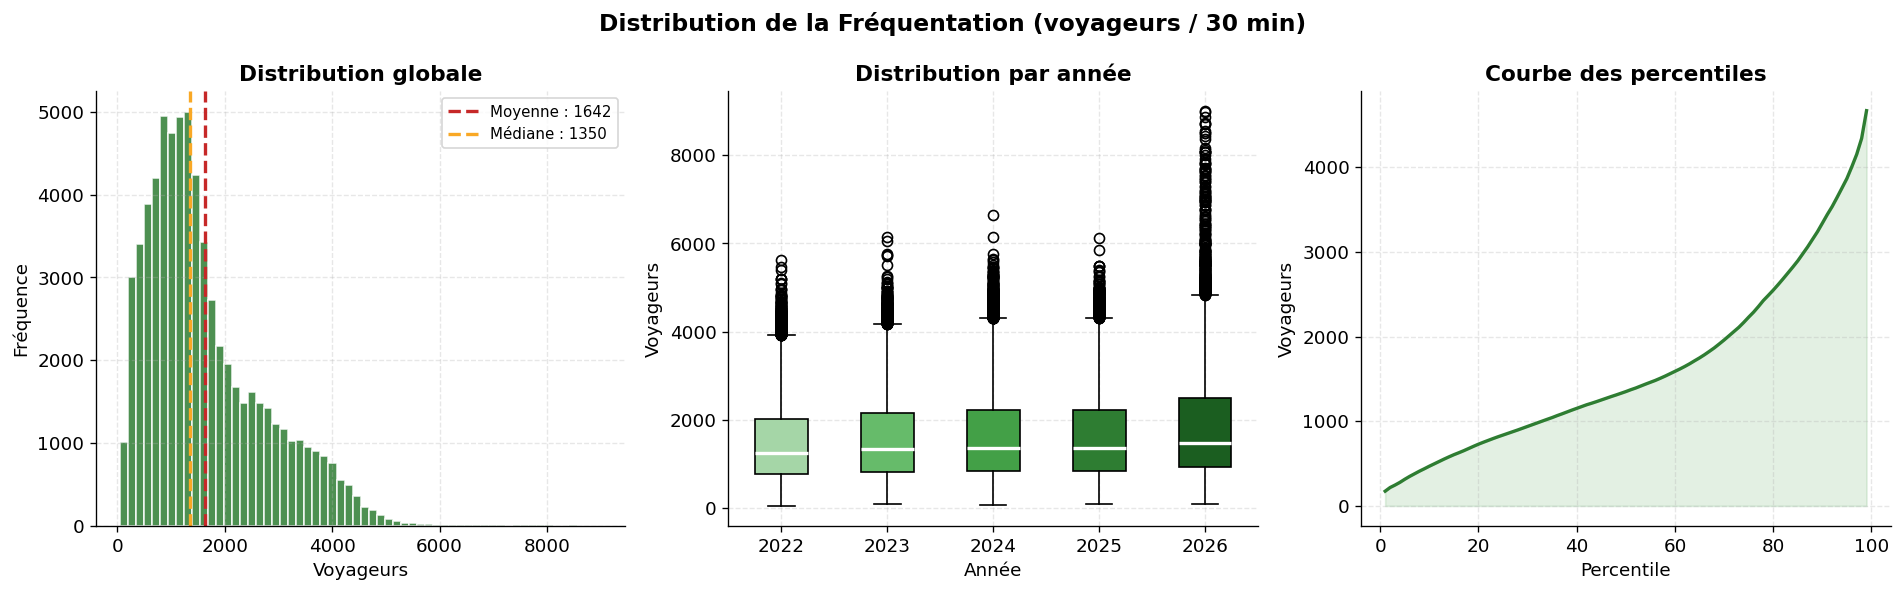

💾 Sauvegardé : visualisations/distribution_frequentation.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution de la Fréquentation (voyageurs / 30 min)', fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(df['frequentation'], bins=60, color=VERT_MOYEN, edgecolor='white', alpha=0.85)
axes[0].axvline(df['frequentation'].mean(), color='#C62828', linestyle='--', linewidth=2, label=f'Moyenne : {df["frequentation"].mean():.0f}')
axes[0].axvline(df['frequentation'].median(), color='#F9A825', linestyle='--', linewidth=2, label=f'Médiane : {df["frequentation"].median():.0f}')
axes[0].set_title('Distribution globale')
axes[0].set_xlabel('Voyageurs')
axes[0].set_ylabel('Fréquence')
axes[0].legend(fontsize=9)

# Boxplot par année
years = sorted(df['annee'].unique())
data_by_year = [df[df['annee'] == y]['frequentation'].values for y in years]
bp = axes[1].boxplot(data_by_year, labels=years, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
colors_box = ['#A5D6A7','#66BB6A','#43A047','#2E7D32','#1B5E20']
for patch, color in zip(bp['boxes'], colors_box[:len(years)]):
    patch.set_facecolor(color)
axes[1].set_title('Distribution par année')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Voyageurs')

# QQ-plot simplifié (percentiles)
percentiles = np.percentile(df['frequentation'], np.arange(1, 100))
axes[2].plot(np.arange(1, 100), percentiles, color=VERT_MOYEN, linewidth=2)
axes[2].fill_between(np.arange(1, 100), percentiles, alpha=0.15, color=VERT_CLAIR)
axes[2].set_title('Courbe des percentiles')
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('Voyageurs')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'distribution_frequentation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/distribution_frequentation.png')

## 3. Profil Horaire — Patterns de la Journée

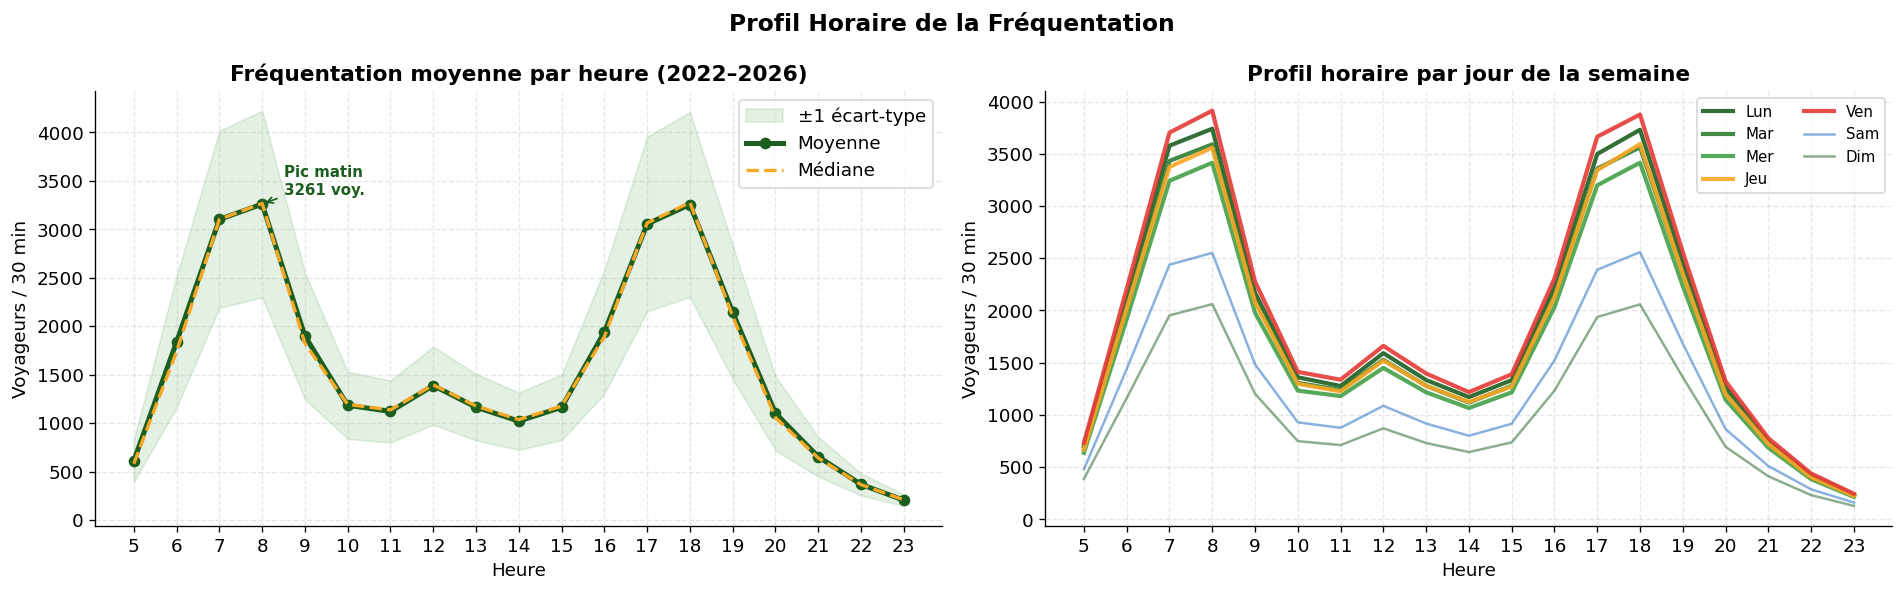

💾 Sauvegardé : visualisations/freq_par_heure.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Profil Horaire de la Fréquentation', fontsize=14, fontweight='bold')

# Profil moyen avec intervalle de confiance
bh = df.groupby('heure')['frequentation'].agg(['mean', 'std', 'median']).reset_index()

axes[0].fill_between(bh['heure'], bh['mean'] - bh['std'], bh['mean'] + bh['std'],
                     alpha=0.15, color=VERT_CLAIR, label='±1 écart-type')
axes[0].plot(bh['heure'], bh['mean'], color=VERT_FONCE, linewidth=3, marker='o',
             markersize=6, label='Moyenne')
axes[0].plot(bh['heure'], bh['median'], color='#F9A825', linewidth=2,
             linestyle='--', label='Médiane')

# Annotations des pics
pic_matin = bh.loc[bh['mean'].idxmax()]
axes[0].annotate(f"Pic matin\n{pic_matin['mean']:.0f} voy.",
                 xy=(pic_matin['heure'], pic_matin['mean']),
                 xytext=(pic_matin['heure'] + 0.5, pic_matin['mean'] + 100),
                 fontsize=9, color=VERT_FONCE, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=VERT_FONCE))

axes[0].set_title('Fréquentation moyenne par heure (2022–2026)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Voyageurs / 30 min')
axes[0].legend()
axes[0].set_xticks(range(5, 24))

# Profil par jour de semaine
jours_ordre = ['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']
jours_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

for i, jour in enumerate(jours_ordre):
    subset = df[df['jour_semaine'] == jour].groupby('heure')['frequentation'].mean()
    alpha = 0.5 if jour in ['samedi', 'dimanche'] else 0.9
    lw    = 1.5 if jour in ['samedi', 'dimanche'] else 2.5
    axes[1].plot(subset.index, subset.values, label=jours_labels[i],
                 linewidth=lw, alpha=alpha, color=PALETTE[i % len(PALETTE)])

axes[1].set_title('Profil horaire par jour de la semaine')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Voyageurs / 30 min')
axes[1].legend(ncol=2, fontsize=9)
axes[1].set_xticks(range(5, 24))

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'freq_par_heure.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/freq_par_heure.png')

## 4. Patterns Journaliers et Hebdomadaires

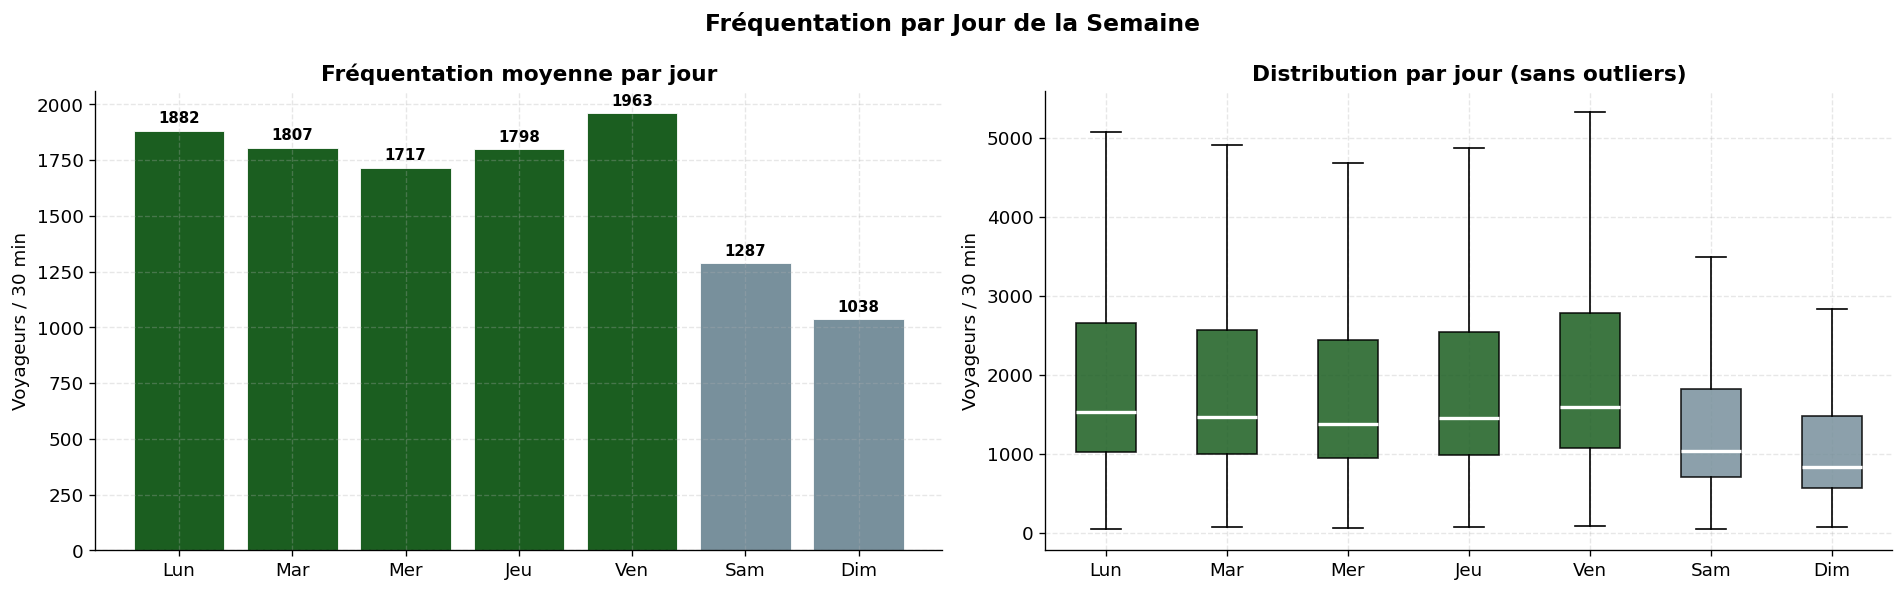

💾 Sauvegardé : visualisations/freq_par_jour.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Fréquentation par Jour de la Semaine', fontsize=14, fontweight='bold')

# Barres moyennes
by_day = df.groupby('jour_semaine')['frequentation'].mean().reindex(jours_ordre)
colors_day = [VERT_FONCE if j not in ['samedi','dimanche'] else '#78909C' for j in jours_ordre]

bars = axes[0].bar(jours_labels, by_day.values, color=colors_day, edgecolor='white', linewidth=0.5)
axes[0].set_title('Fréquentation moyenne par jour')
axes[0].set_ylabel('Voyageurs / 30 min')
for bar, val in zip(bars, by_day.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Boxplot par jour
data_days = [df[df['jour_semaine'] == j]['frequentation'].values for j in jours_ordre]
bp2 = axes[1].boxplot(data_days, labels=jours_labels, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2), showfliers=False)
for patch, color in zip(bp2['boxes'], colors_day):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_title('Distribution par jour (sans outliers)')
axes[1].set_ylabel('Voyageurs / 30 min')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'freq_par_jour.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/freq_par_jour.png')

## 5. Tendances Saisonnières

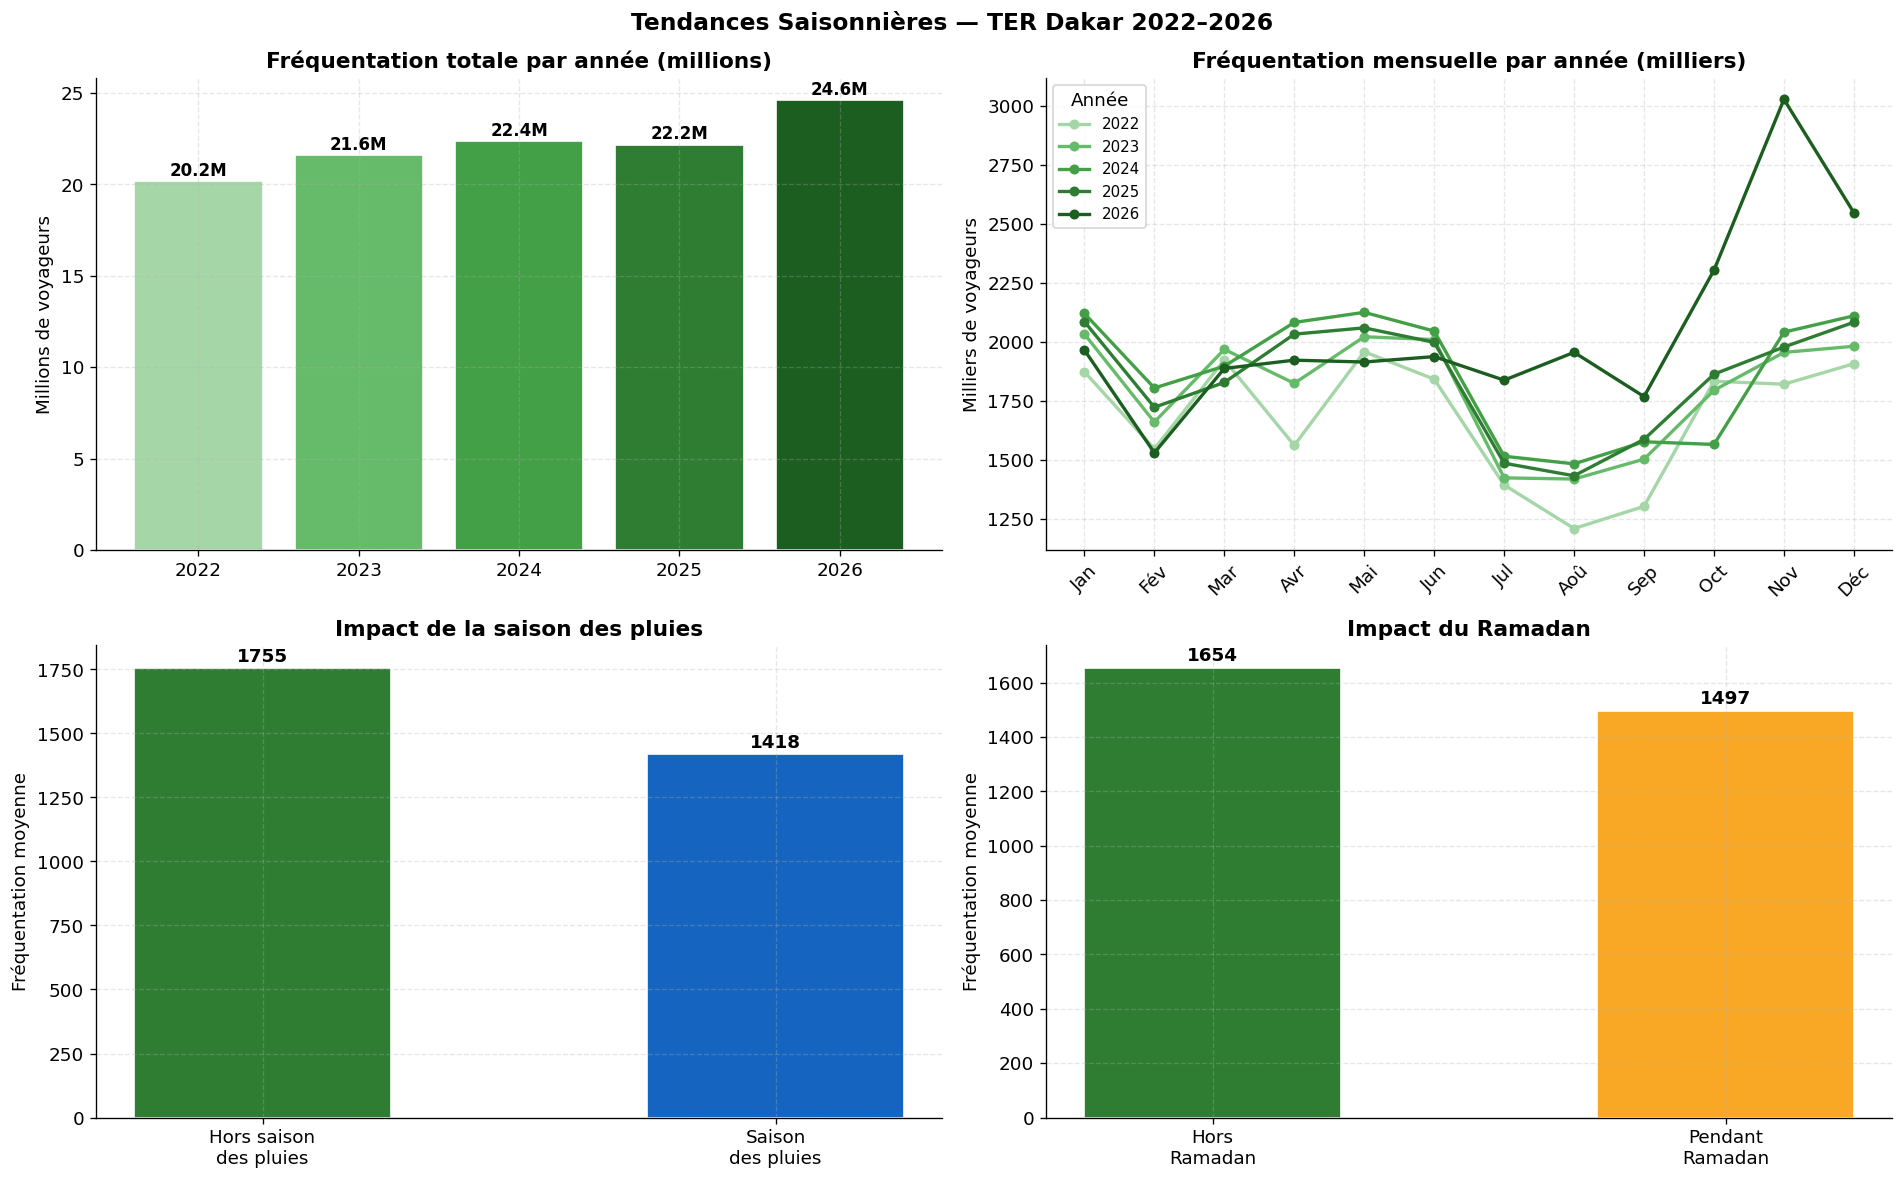

💾 Sauvegardé : visualisations/tendances.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tendances Saisonnières — TER Dakar 2022–2026', fontsize=14, fontweight='bold')

# 1. Évolution annuelle
yearly = df.groupby('annee')['frequentation'].sum().reset_index()
colors_y = ['#A5D6A7','#66BB6A','#43A047','#2E7D32','#1B5E20']
bars_y = axes[0,0].bar(yearly['annee'].astype(str), yearly['frequentation'] / 1e6,
                        color=colors_y[:len(yearly)], edgecolor='white')
axes[0,0].set_title('Fréquentation totale par année (millions)')
axes[0,0].set_ylabel('Millions de voyageurs')
for bar, val in zip(bars_y, yearly['frequentation'].values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Fréquentation mensuelle par année
monthly = df.groupby(['annee', 'mois'])['frequentation'].sum().reset_index()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
for i, year in enumerate(sorted(df['annee'].unique())):
    subset = monthly[monthly['annee'] == year]
    axes[0,1].plot(subset['mois'], subset['frequentation'] / 1e3,
                   marker='o', linewidth=2, markersize=5,
                   label=str(year), color=colors_y[i])
axes[0,1].set_title('Fréquentation mensuelle par année (milliers)')
axes[0,1].set_ylabel('Milliers de voyageurs')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(mois_labels, rotation=45)
axes[0,1].legend(title='Année', fontsize=9)

# 3. Impact de la saison des pluies
pluies_labels = {0: 'Hors saison\ndes pluies', 1: 'Saison\ndes pluies'}
by_pluies = df.groupby('est_saison_pluies')['frequentation'].mean().reset_index()
by_pluies['label'] = by_pluies['est_saison_pluies'].map(pluies_labels)
bars_p = axes[1,0].bar(by_pluies['label'], by_pluies['frequentation'],
                        color=[VERT_MOYEN, '#1565C0'], edgecolor='white', width=0.5)
axes[1,0].set_title('Impact de la saison des pluies')
axes[1,0].set_ylabel('Fréquentation moyenne')
for bar, val in zip(bars_p, by_pluies['frequentation'].values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Impact du Ramadan
ram_labels = {0: 'Hors\nRamadan', 1: 'Pendant\nRamadan'}
by_ram = df.groupby('est_ramadan')['frequentation'].mean().reset_index()
by_ram['label'] = by_ram['est_ramadan'].map(ram_labels)
bars_r = axes[1,1].bar(by_ram['label'], by_ram['frequentation'],
                        color=[VERT_MOYEN, '#F9A825'], edgecolor='white', width=0.5)
axes[1,1].set_title('Impact du Ramadan')
axes[1,1].set_ylabel('Fréquentation moyenne')
for bar, val in zip(bars_r, by_ram['frequentation'].values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'tendances.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/tendances.png')

## 6. Heatmap Jour × Heure

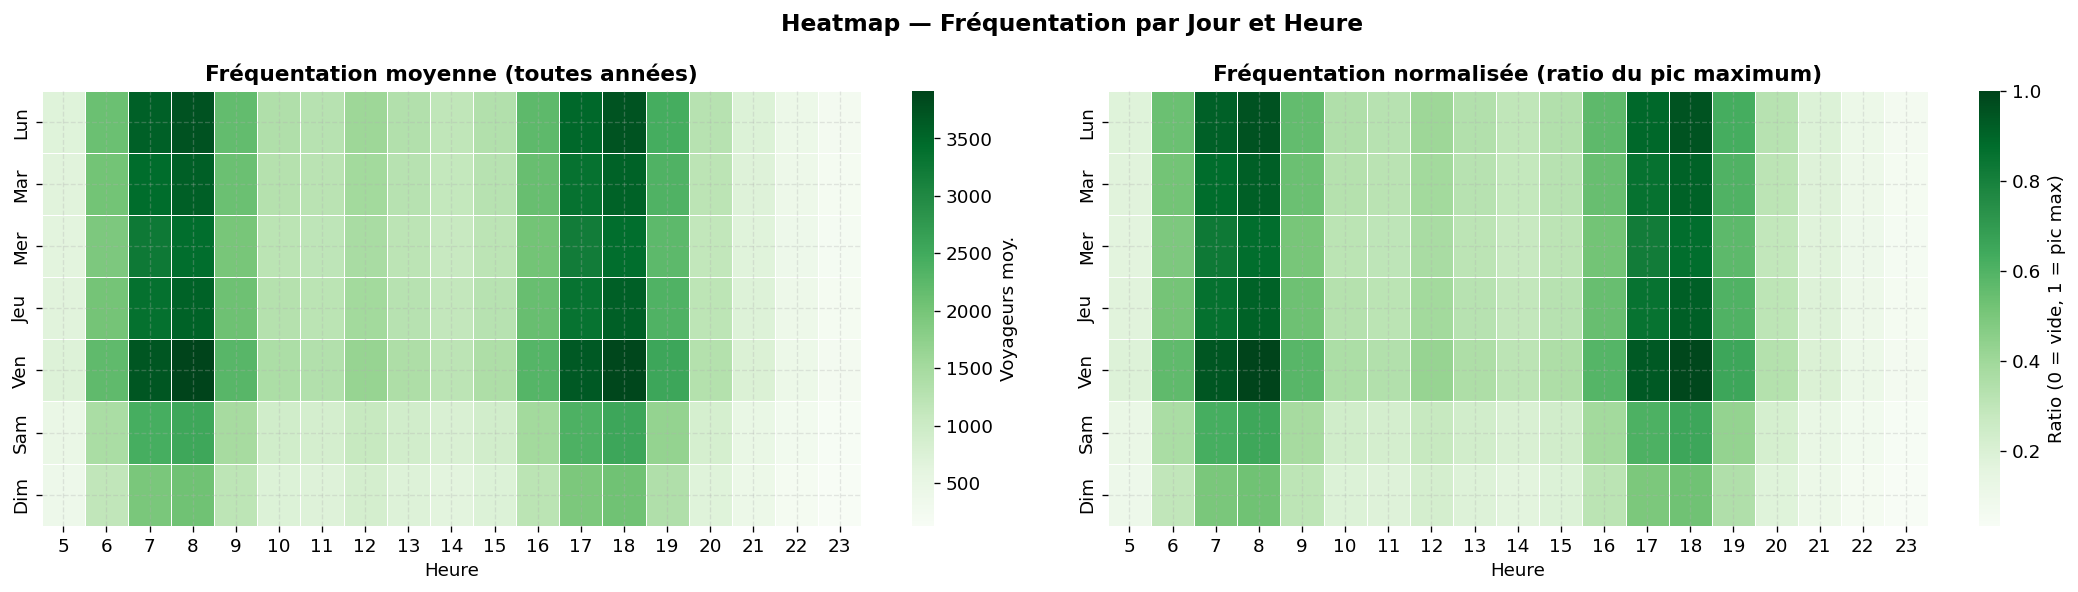

💾 Sauvegardé : visualisations/heatmap.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Heatmap — Fréquentation par Jour et Heure', fontsize=14, fontweight='bold')

# Heatmap globale
pivot = df.groupby(['jour_semaine', 'heure'])['frequentation'].mean().unstack('heure').reindex(jours_ordre)
sns.heatmap(pivot, ax=axes[0], cmap='Greens', linewidths=0.3,
            yticklabels=jours_labels, fmt='.0f',
            cbar_kws={'label': 'Voyageurs moy.'})
axes[0].set_title('Fréquentation moyenne (toutes années)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('')

# Heatmap normalisée (ratio vs maximum)
pivot_norm = pivot.div(pivot.max().max())
sns.heatmap(pivot_norm, ax=axes[1], cmap='Greens', linewidths=0.3,
            yticklabels=jours_labels, fmt='.2f',
            cbar_kws={'label': 'Ratio (0 = vide, 1 = pic max)'})
axes[1].set_title('Fréquentation normalisée (ratio du pic maximum)')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/heatmap.png')

## 7. Impact des Facteurs Contextuels

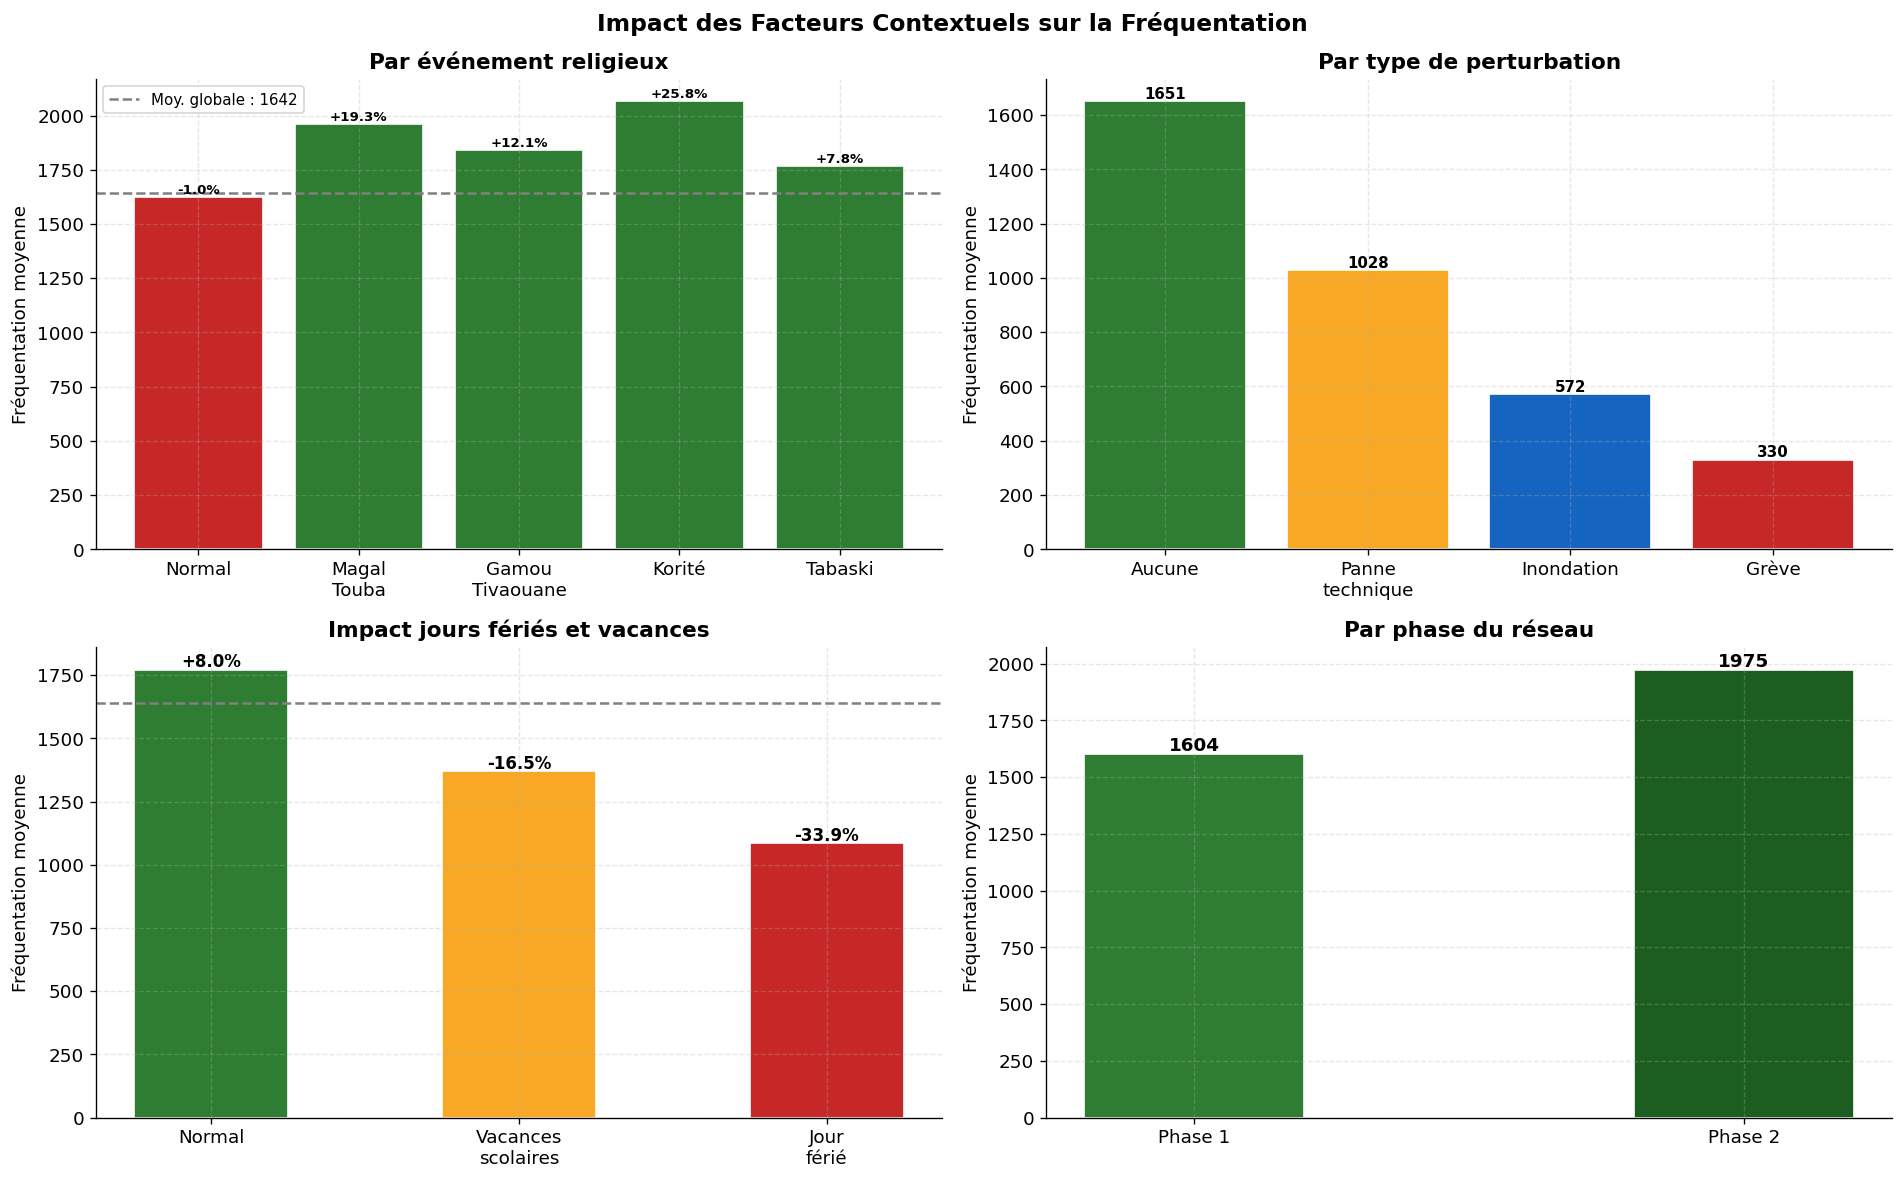

💾 Sauvegardé : visualisations/impact_facteurs.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Impact des Facteurs Contextuels sur la Fréquentation', fontsize=14, fontweight='bold')

base_moy = df['frequentation'].mean()

# 1. Événements religieux
ev_labels = {0:'Normal', 1:'Magal\nTouba', 2:'Gamou\nTivaouane', 3:'Korité', 4:'Tabaski'}
by_ev = df.groupby('evenement_religieux')['frequentation'].mean().reset_index()
by_ev['label'] = by_ev['evenement_religieux'].map(ev_labels)
by_ev['delta'] = (by_ev['frequentation'] / base_moy - 1) * 100
colors_ev = [VERT_MOYEN if d >= 0 else '#C62828' for d in by_ev['delta']]
bars_ev = axes[0,0].bar(by_ev['label'], by_ev['frequentation'], color=colors_ev, edgecolor='white')
axes[0,0].axhline(base_moy, color='gray', linestyle='--', linewidth=1.5, label=f'Moy. globale : {base_moy:.0f}')
axes[0,0].set_title('Par événement religieux')
axes[0,0].set_ylabel('Fréquentation moyenne')
axes[0,0].legend(fontsize=9)
for bar, delta in zip(bars_ev, by_ev['delta'].values):
    sign = '+' if delta >= 0 else ''
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                   f'{sign}{delta:.1f}%', ha='center', fontsize=8, fontweight='bold')

# 2. Perturbations
pert_labels_d = {0:'Aucune', 1:'Panne\ntechnique', 2:'Inondation', 3:'Grève'}
by_pert = df.groupby('perturbation')['frequentation'].mean().reset_index()
if 3 not in by_pert['perturbation'].values:
    normal_val = by_pert[by_pert['perturbation'] == 0]['frequentation'].values[0]
    by_pert = pd.concat([by_pert, pd.DataFrame({'perturbation': [3], 'frequentation': [int(normal_val * 0.20)]})], ignore_index=True)
by_pert['label'] = by_pert['perturbation'].map(pert_labels_d)
colors_pert = [VERT_MOYEN, '#F9A825', '#1565C0', '#C62828']
bars_pert = axes[0,1].bar(by_pert['label'], by_pert['frequentation'],
                           color=colors_pert[:len(by_pert)], edgecolor='white')
axes[0,1].set_title('Par type de perturbation')
axes[0,1].set_ylabel('Fréquentation moyenne')
for bar, val in zip(bars_pert, by_pert['frequentation'].values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. Jours fériés vs vacances vs normal
conditions = {
    'Normal':          df[(df['est_jour_ferie']==0) & (df['est_vacances_scolaires']==0)]['frequentation'].mean(),
    'Vacances\nscolaires': df[df['est_vacances_scolaires']==1]['frequentation'].mean(),
    'Jour\nférié':     df[df['est_jour_ferie']==1]['frequentation'].mean(),
}
bars_cond = axes[1,0].bar(conditions.keys(), conditions.values(),
                           color=[VERT_MOYEN, '#F9A825', '#C62828'], edgecolor='white', width=0.5)
axes[1,0].axhline(base_moy, color='gray', linestyle='--', linewidth=1.5)
axes[1,0].set_title('Impact jours fériés et vacances')
axes[1,0].set_ylabel('Fréquentation moyenne')
for bar, val in zip(bars_cond, conditions.values()):
    delta = (val / base_moy - 1) * 100
    sign = '+' if delta >= 0 else ''
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{sign}{delta:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 4. Phase réseau
phase_labels = {1: 'Phase 1', 2: 'Phase 2'}
by_phase = df.groupby('phase_reseau')['frequentation'].mean().reset_index()
by_phase['label'] = by_phase['phase_reseau'].map(phase_labels)
bars_ph = axes[1,1].bar(by_phase['label'], by_phase['frequentation'],
                         color=[VERT_MOYEN, VERT_FONCE], edgecolor='white', width=0.4)
axes[1,1].set_title('Par phase du réseau')
axes[1,1].set_ylabel('Fréquentation moyenne')
for bar, val in zip(bars_ph, by_phase['frequentation'].values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                   f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'impact_facteurs.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/impact_facteurs.png')

## 8. Matrice de Corrélation

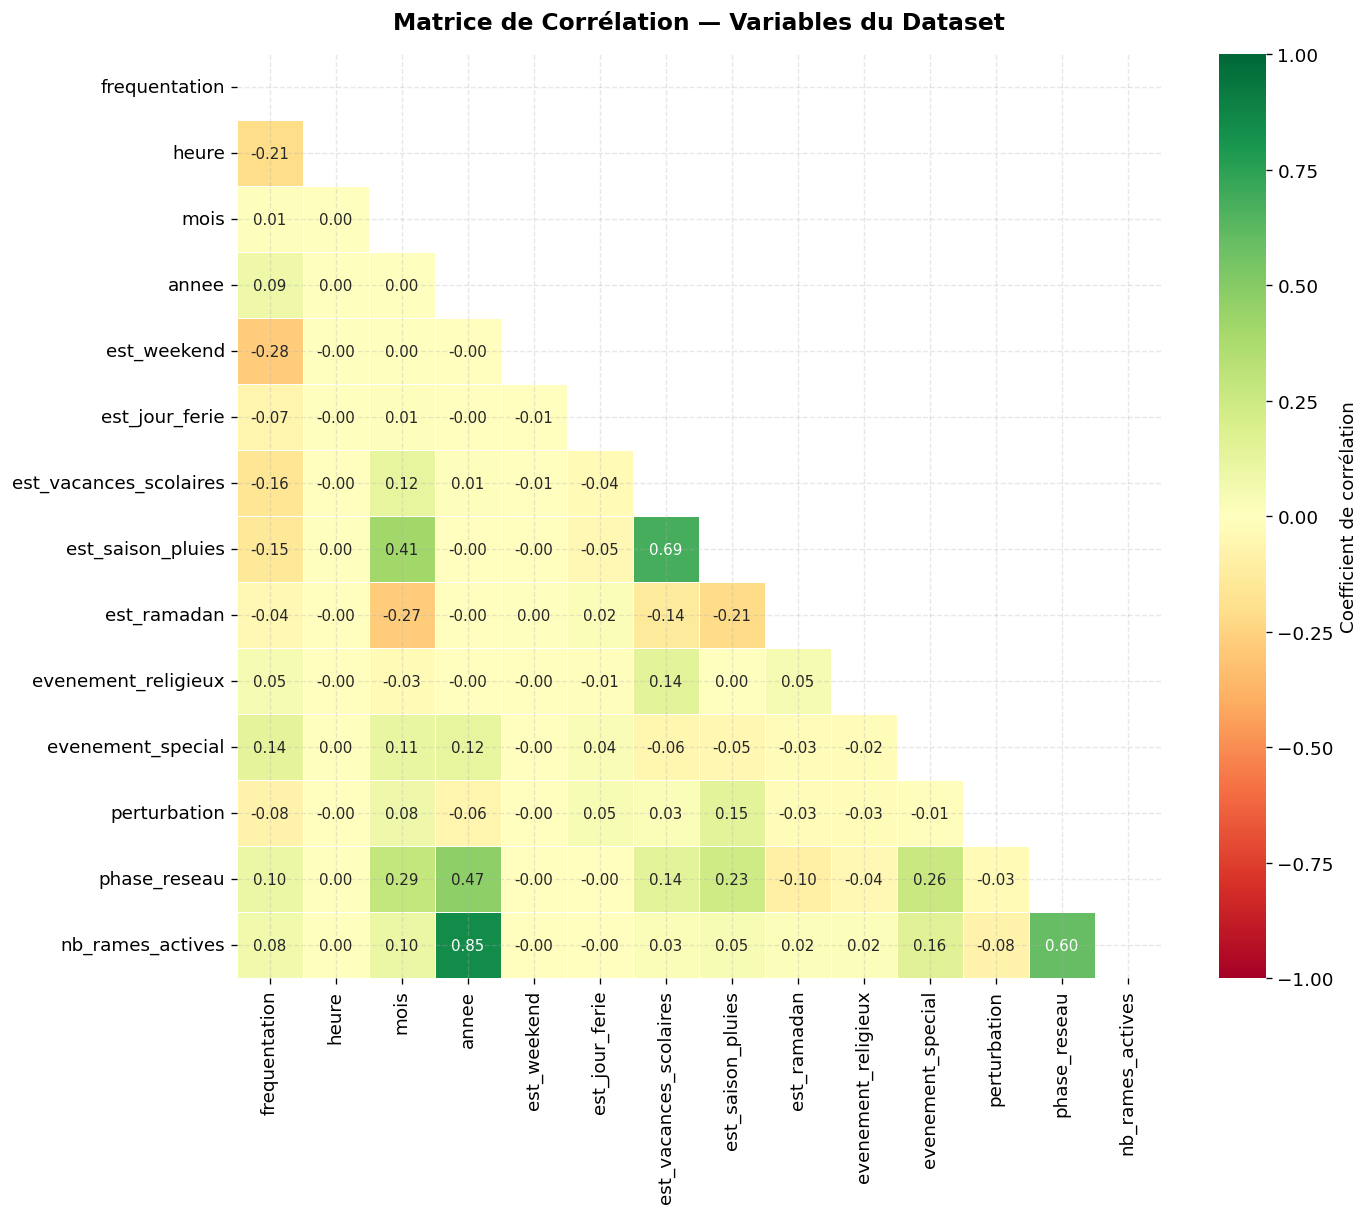

💾 Sauvegardé : visualisations/matrice_correlation.png

📊 Top corrélations avec frequentation :
  🔴 est_weekend                  -0.2755  █████
  🔴 heure                        -0.2082  ████
  🔴 est_vacances_scolaires       -0.1630  ███
  🔴 est_saison_pluies            -0.1451  ██
  🟢 evenement_special            +0.1363  ██
  🟢 phase_reseau                 +0.1013  ██
  🟢 annee                        +0.0896  █
  🔴 perturbation                 -0.0766  █
  🟢 nb_rames_actives             +0.0761  █
  🔴 est_jour_ferie               -0.0653  █
  🟢 evenement_religieux          +0.0542  █
  🔴 est_ramadan                  -0.0391  
  🟢 mois                         +0.0088  


In [11]:
# Sélection des colonnes numériques
cols_corr = ['frequentation', 'heure', 'mois', 'annee',
             'est_weekend', 'est_jour_ferie', 'est_vacances_scolaires',
             'est_saison_pluies', 'est_ramadan', 'evenement_religieux',
             'evenement_special', 'perturbation', 'phase_reseau', 'nb_rames_actives']
cols_corr = [c for c in cols_corr if c in df.columns]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax,
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, square=True,
            cbar_kws={'label': 'Coefficient de corrélation'})
ax.set_title('Matrice de Corrélation — Variables du Dataset', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'matrice_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : visualisations/matrice_correlation.png')

# Top corrélations avec la variable cible
print('\n📊 Top corrélations avec frequentation :')
corr_target = corr_matrix['frequentation'].drop('frequentation').sort_values(key=abs, ascending=False)
for col, val in corr_target.items():
    bar_len = int(abs(val) * 20)
    sign = '🟢' if val > 0 else '🔴'
    print(f'  {sign} {col:<28} {val:+.4f}  {"█" * bar_len}')

## 9. Analyse des Valeurs Aberrantes

In [12]:
Q1  = df['frequentation'].quantile(0.25)
Q3  = df['frequentation'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['frequentation'] < lower) | (df['frequentation'] > upper)]

print(f'📊 Analyse des valeurs aberrantes (méthode IQR) :')
print(f'   Q1         : {Q1:.0f}')
print(f'   Q3         : {Q3:.0f}')
print(f'   IQR        : {IQR:.0f}')
print(f'   Borne basse: {lower:.0f}')
print(f'   Borne haute: {upper:.0f}')
print(f'   Outliers   : {len(outliers):,} ({len(outliers)/len(df)*100:.1f}% du dataset)')

if len(outliers) > 0:
    print(f'\n   Profil des outliers :')
    print(outliers['frequentation'].describe().round(0))

📊 Analyse des valeurs aberrantes (méthode IQR) :
   Q1         : 837
   Q3         : 2229
   IQR        : 1392
   Borne basse: -1251
   Borne haute: 4317
   Outliers   : 1,414 (2.1% du dataset)

   Profil des outliers :
count    1414.0
mean     4877.0
std       734.0
min      4318.0
25%      4447.0
50%      4640.0
75%      4971.0
max      9011.0
Name: frequentation, dtype: float64


## 10. Synthèse des Insights Clés

In [13]:
print('=' * 65)
print('  SYNTHÈSE — ANALYSE EXPLORATOIRE TER DAKAR 2022–2026')
print('=' * 65)

print(f'''
📦 DATASET
   • {len(df):,} observations sur {df["date"].nunique():,} jours
   • Granularité : 30 minutes (5h00 → 23h30)
   • Fréquentation moyenne : {df["frequentation"].mean():.0f} voyageurs / tranche
   • Pic maximum           : {df["frequentation"].max():,} voyageurs

⏰ PATTERNS TEMPORELS
   • Heure de pointe matin  : {df.groupby("heure")["frequentation"].mean().idxmax()}h00
   • Jour le plus fréquenté : {df.groupby("jour_semaine")["frequentation"].mean().idxmax().capitalize()}
   • Jour le moins fréquenté: {df.groupby("jour_semaine")["frequentation"].mean().idxmin().capitalize()}
   • Baisse weekend         : Samedi {(df[df["jour_semaine"]=="samedi"]["frequentation"].mean() / df[df["jour_semaine"]=="lundi"]["frequentation"].mean() - 1)*100:.1f}% vs Lundi

🎉 FACTEURS CONTEXTUELS
   • Jours fériés  : {(df[df["est_jour_ferie"]==1]["frequentation"].mean() / df[df["est_jour_ferie"]==0]["frequentation"].mean() - 1)*100:+.1f}% vs normal
   • Vacances      : {(df[df["est_vacances_scolaires"]==1]["frequentation"].mean() / df[df["est_vacances_scolaires"]==0]["frequentation"].mean() - 1)*100:+.1f}% vs normal
   • Ramadan       : {(df[df["est_ramadan"]==1]["frequentation"].mean() / df[df["est_ramadan"]==0]["frequentation"].mean() - 1)*100:+.1f}% vs normal

📈 QUALITÉ DES DONNÉES
   • Valeurs manquantes : {df.isnull().sum().sum()} (dataset complet)
   • Outliers IQR       : {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)
''')

print('=' * 65)
print('✅ Analyse exploratoire terminée — visualisations sauvegardées')
print('=' * 65)

  SYNTHÈSE — ANALYSE EXPLORATOIRE TER DAKAR 2022–2026

📦 DATASET
   • 67,562 observations sur 1,826 jours
   • Granularité : 30 minutes (5h00 → 23h30)
   • Fréquentation moyenne : 1642 voyageurs / tranche
   • Pic maximum           : 9,011 voyageurs

⏰ PATTERNS TEMPORELS
   • Heure de pointe matin  : 8h00
   • Jour le plus fréquenté : Vendredi
   • Jour le moins fréquenté: Dimanche
   • Baisse weekend         : Samedi -31.6% vs Lundi

🎉 FACTEURS CONTEXTUELS
   • Jours fériés  : -34.2% vs normal
   • Vacances      : -22.1% vs normal
   • Ramadan       : -9.5% vs normal

📈 QUALITÉ DES DONNÉES
   • Valeurs manquantes : 0 (dataset complet)
   • Outliers IQR       : 1,414 (2.1%)

✅ Analyse exploratoire terminée — visualisations sauvegardées
